In [ ]:
# Montar Google Drive para acceder al dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importación de librerias
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [ ]:
# ---------------------------------------------------------------------------
# Función: extraer vector de features de una imagen usando histograma HSV
# Justificación: los histogramas HSV son invariantes a cambios de iluminación
# y capturan distribución de color, que distingue tejido sano de enfermo.
# ---------------------------------------------------------------------------

def extraer_features_hsv(ruta_imagen: str, bins: int = 32) -> np.ndarray:
    """
    Lee una imagen, la convierte a HSV y devuelve el histograma
    aplanado como vector de features de longitud bins*3.
    """
    img = cv2.imread(ruta_imagen)
    if img is None:
        return None
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    histograma = []
    for canal in range(3):  # H, S, V
        hist = cv2.calcHist([img_hsv], [canal], None, [bins], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        histograma.extend(hist)
    return np.array(histograma)



DATASET_PATH = "/content/drive/MyDrive/RootKit/PlantVillage"
CLASES = sorted(os.listdir(DATASET_PATH))
MAX_POR_CLASE = 200  # muestreo para no saturar RAM en Colab

features_list = []
etiquetas_list = []

for idx_clase, nombre_clase in enumerate(CLASES):
    ruta_clase = os.path.join(DATASET_PATH, nombre_clase)
    imagenes = os.listdir(ruta_clase)[:MAX_POR_CLASE]
    for nombre_img in imagenes:
        ruta_img = os.path.join(ruta_clase, nombre_img)
        feat = extraer_features_hsv(ruta_img)
        if feat is not None:
            features_list.append(feat)
            etiquetas_list.append(idx_clase)

X = np.array(features_list)
y = np.array(etiquetas_list)
print(f"Shape del dataset de features: {X.shape}")
print(f"Clases encontradas: {len(CLASES)}")

Shape del dataset de features: (2952, 96)
Clases encontradas: 15


In [ ]:
# ---------------------------------------------------------------------------
# Normalización Z-score seguida de PCA a 50 componentes.
# PCA reduce la dimensionalidad de bins*3=96 a 50, eliminando correlaciones
# entre canales y acelerando la convergencia del K-Means.
# ---------------------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza_explicada = np.sum(pca.explained_variance_ratio_) * 100
print(f"Varianza explicada con 50 componentes: {varianza_explicada:.2f}%")

Varianza explicada con 50 componentes: 97.94%


In [ ]:
# ---------------------------------------------------------------------------
# K-Means con k=15: un cluster por clase esperada del dataset PlantVillage.
# Se evalúa con Silhouette Score: métrica en [-1, 1] donde valores > 0.2
# indican separación aceptable entre clusters.
# ---------------------------------------------------------------------------

kmeans_v1 = KMeans(n_clusters=15, random_state=42, n_init=10, max_iter=300)
kmeans_v1.fit(X_pca)

score_v1 = silhouette_score(X_pca, kmeans_v1.labels_, sample_size=2000, random_state=42)
print(f"Silhouette Score (k=15): {score_v1:.4f}")

Silhouette Score (k=15): 0.0814


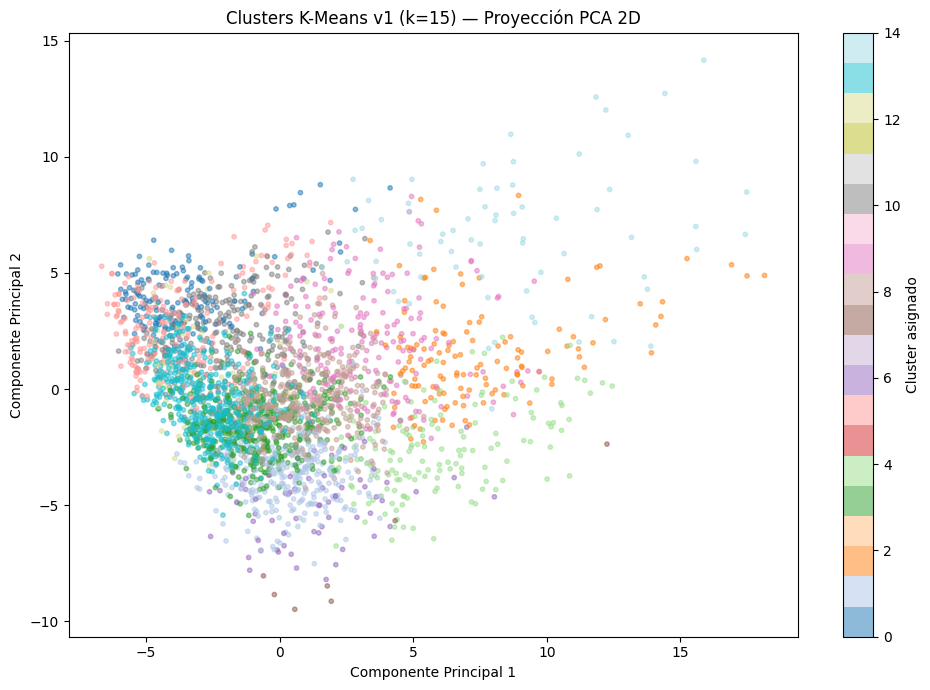

In [ ]:
# Reducción adicional a 2 componentes solo para visualización
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_v1.labels_, cmap="tab20", alpha=0.5, s=10)
plt.colorbar(scatter, label="Cluster asignado")
plt.title("Clusters K-Means v1 (k=15) — Proyección PCA 2D")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/RootKit/reports/kmeans_v1_pca2d.png", dpi=150)
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# Búsqueda del k óptimo mediante Silhouette Score en k = {5, 10, 15}
# ---------------------------------------------------------------------------
import pickle

valores_k = [5, 10, 15]
resultados_k = {}

for k in valores_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X_pca)
    score = silhouette_score(X_pca, km.labels_, sample_size=2000, random_state=42)
    resultados_k[k] = {"modelo": km, "silhouette": score}
    print(f"k={k:2d} | Silhouette Score: {score:.4f}")

# Selección del mejor k
mejor_k = max(resultados_k, key=lambda k: resultados_k[k]["silhouette"])
kmeans_final = resultados_k[mejor_k]["modelo"]
print(f"\nMejor k seleccionado: {mejor_k} (Silhouette: {resultados_k[mejor_k]['silhouette']:.4f})")

k= 5 | Silhouette Score: 0.0748
k=10 | Silhouette Score: 0.0729
k=15 | Silhouette Score: 0.0814

Mejor k seleccionado: 15 (Silhouette: 0.0814)


In [ ]:
# ---------------------------------------------------------------------------
# Exportación del modelo, del scaler y del PCA
# Los tres objetos son necesarios para reproducir el pipeline en la app web.
# ---------------------------------------------------------------------------

MODELS_PATH = "/content/drive/MyDrive/RootKit/models"
os.makedirs(MODELS_PATH, exist_ok=True)

with open(f"{MODELS_PATH}/clustering_kmeans.pkl", "wb") as f:
    pickle.dump(kmeans_final, f)

with open(f"{MODELS_PATH}/clustering_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open(f"{MODELS_PATH}/clustering_pca.pkl", "wb") as f:
    pickle.dump(pca, f)

print("Modelos exportados correctamente en Drive/models/")

Modelos exportados correctamente en Drive/models/


In [ ]:
import tensorflow as tf
import numpy as np

MODEL_PATH = "/content/drive/MyDrive/RootKit/models/"
cnn = tf.keras.models.load_model(MODEL_PATH + "cnn_final.h5")

# Pasar un tensor dummy para construir el grafo completo
dummy = np.zeros((1, 128, 128, 3), dtype=np.float32)
_ = cnn(dummy, training=False)

# Ahora sí se puede inspeccionar output_shape
for i, layer in enumerate(cnn.layers):
    try:
        shape = str(layer.output_shape)
    except AttributeError:
        shape = "N/A"
    print(f"[{i:3d}]  {layer.name:45s}  {shape}")

[  0]  conv2d_6                                       N/A
[  1]  batch_normalization                            N/A
[  2]  max_pooling2d_6                                N/A
[  3]  conv2d_7                                       N/A
[  4]  batch_normalization_1                          N/A
[  5]  max_pooling2d_7                                N/A
[  6]  conv2d_8                                       N/A
[  7]  batch_normalization_2                          N/A
[  8]  max_pooling2d_8                                N/A
[  9]  conv2d_9                                       N/A
[ 10]  batch_normalization_3                          N/A
[ 11]  max_pooling2d_9                                N/A
[ 12]  flatten_2                                      N/A
[ 13]  dense_4                                        N/A
[ 14]  batch_normalization_4                          N/A
[ 15]  dropout_2                                      N/A
[ 16]  dense_5                                        N/A
[ 17]  dropout